# K05_00 – Logistische Regression: Äpfel-Beispiel

Update am 27. Mai 2026

## Lernziele
- binäre Klassifikation verstehen
- Wahrscheinlichkeiten und Klassenentscheidungen unterscheiden
- die Rolle der Sigmoid-Funktion intuitiv einordnen
- Accuracy und Konfusionsmatrix interpretieren

Wir betrachten ein einfaches Beispiel:
Ein Apfel wird anhand eines Merkmals klassifiziert.

- **Klasse 0**: noch nicht genießbar
- **Klasse 1**: genießbar

## 1. Bibliotheken importieren
Wir verwenden `LogisticRegression` aus `scikit-learn`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score

## 2. Beispieldaten erzeugen

Wir nehmen eine Stichprobe von 14 Äpfeln und prüfen, ob die Äpfel genießbar sind (ja = 1, nein = 0)

In [2]:
X = np.array([[1], [2], [3], [4], [5], [6], [7], [8], [9], [10], [11], [12], [13], [14]])
y = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1])

print("Shape von X:", X.shape)
print("Shape von y:", y.shape)
print("X:", X.ravel())
print("y:", y)

Shape von X: (14, 1)
Shape von y: (14,)
X: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]
y: [0 0 0 0 0 0 1 0 1 1 1 1 1 1]


## 3. Daten visualisieren

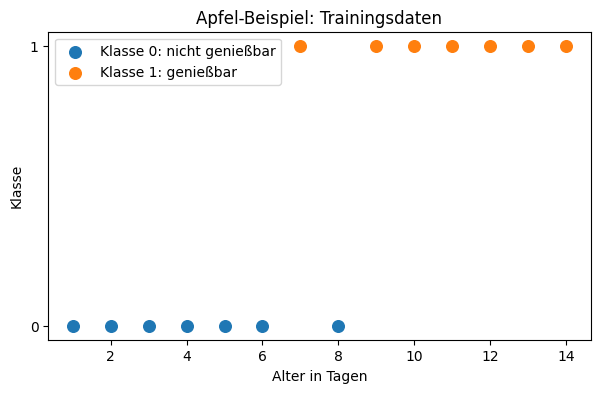

In [3]:
plt.figure(figsize=(7, 4))
plt.scatter(X[y == 0], y[y == 0], label="Klasse 0: nicht genießbar", s=70)
plt.scatter(X[y == 1], y[y == 1], label="Klasse 1: genießbar", s=70)
plt.xlabel("Alter in Tagen")
plt.ylabel("Klasse")
plt.yticks([0, 1])
plt.legend()
plt.title("Apfel-Beispiel: Trainingsdaten")
plt.show()

## 4. Modell trainieren
Wir trainieren jetzt eine logistische Regression.

In [4]:
clf = LogisticRegression()
clf.fit(X, y)

print("Intercept:", clf.intercept_[0])
print("Koeffizient:", clf.coef_[0, 0])

Intercept: -6.957332749368031
Koeffizient: 0.9276468592239987


### Wie Intercept und Koeffizient in die Vorhersage einfließen

Das Modell rechnet in zwei Schritten:

**Schritt 1 – Lineare Kombination:**
```
z = β₀ + β₁ · x
```

**Schritt 2 – Sigmoid-Funktion:**
```
P(y=1) = 1 / (1 + e^(−z))
```

Intercept und Koeffizient bestimmen gemeinsam `z` –
die Sigmoid-Funktion wandelt `z` in eine Wahrscheinlichkeit zwischen 0 und 1 um.


In [5]:
# Gelernte Parameter
beta_0 = clf.intercept_[0]   # Intercept
beta_1 = clf.coef_[0, 0]     # Koeffizient

# Drei Beispiel-Eingabewerte
beispiele = [5, 7.5, 10]

print(f"β₀ (Intercept):   {beta_0:.4f}")
print(f"β₁ (Koeffizient): {beta_1:.4f}")
print()
print(f"{'x':>6}  {'z = β₀ + β₁·x':>18}  {'P = sigmoid(z)':>16}")
print("-" * 46)

for x in beispiele:
    z = beta_0 + beta_1 * x          # Schritt 1: lineare Kombination
    P = 1 / (1 + np.exp(-z))         # Schritt 2: Sigmoid-Funktion
    print(f"{x:>6.1f}  {z:>18.4f}  {P:>15.4f}  ({P*100:.1f} %)")

print()
print("Kontrolle: predict_proba() liefert dieselben Werte:")
kontrolle = clf.predict_proba(np.array(beispiele).reshape(-1, 1))[:, 1]
for x, p in zip(beispiele, kontrolle):
    print(f"  x={x}: {p:.4f}")


β₀ (Intercept):   -6.9573
β₁ (Koeffizient): 0.9276

     x       z = β₀ + β₁·x    P = sigmoid(z)
----------------------------------------------
   5.0             -2.3191           0.0896  (9.0 %)
   7.5              0.0000           0.5000  (50.0 %)
  10.0              2.3191           0.9104  (91.0 %)

Kontrolle: predict_proba() liefert dieselben Werte:
  x=5: 0.0896
  x=7.5: 0.5000
  x=10: 0.9104


## 5. Wahrscheinlichkeiten berechnen
Die logistische Regression sagt zunächst **Wahrscheinlichkeiten** voraus.
Erst danach wird daraus eine Klasse 0 oder 1 abgeleitet.

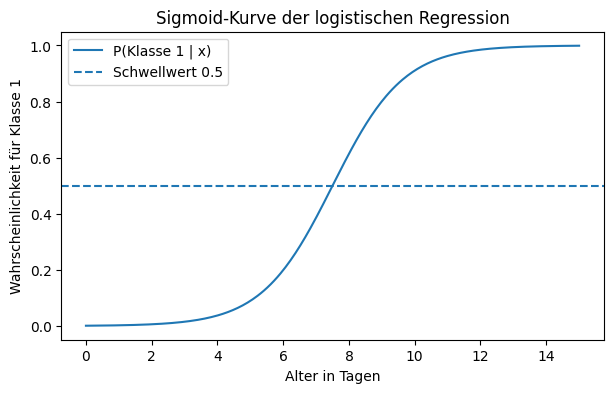

In [6]:
X_test = np.linspace(0, 15, 300).reshape(-1, 1)
proba = clf.predict_proba(X_test)[:, 1] # gib für jeden Datenpunkt in X_test die Wahrscheinlichkeit für Klasse = 1 zurück.

plt.figure(figsize=(7, 4))
plt.plot(X_test, proba, label="P(Klasse 1 | x)")
plt.axhline(0.5, linestyle="--", label="Schwellwert 0.5")
plt.xlabel("Alter in Tagen")
plt.ylabel("Wahrscheinlichkeit für Klasse 1")
plt.title("Sigmoid-Kurve der logistischen Regression")
plt.legend()
plt.show()

### Erläuterung: `clf.predict_proba(X_test)[:, 1]`

`predict_proba()` gibt für jeden Datenpunkt **zwei Wahrscheinlichkeiten** zurück – eine pro Klasse:

Klasse 0   Klasse 1

Shape: `(n_samples, 2)` – die Werte pro Zeile addieren sich immer zu **1.0**.

`[:, 1]` ist NumPy-Slicing und bedeutet: *„alle Zeilen, nur Spalte 1"* –
also nur die Wahrscheinlichkeit für **Klasse 1**.

Die Wahrscheinlichkeit für Klasse 0 ist nicht nötig:
`P(Klasse 0) = 1 − P(Klasse 1)`

> **Merksatz:** `predict_proba()[:, 1]` liefert pro Datenpunkt genau eine Zahl:
> *„Wie sicher ist das Modell, dass es sich um den positiven Fall handelt?"*

## 6. Klassenentscheidung und Entscheidungsgrenze
Mit `predict()` wird aus der Wahrscheinlichkeit eine Klassenentscheidung.

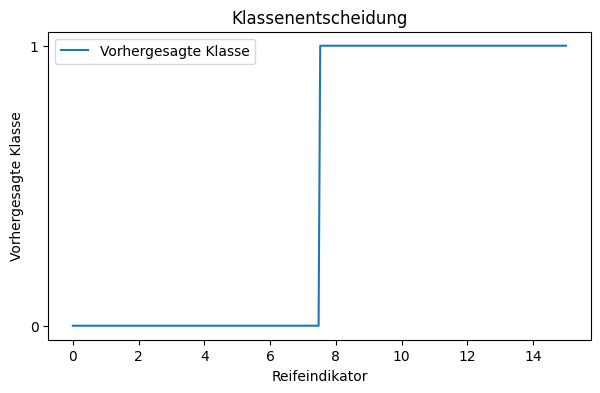

In [7]:
pred_curve = clf.predict(X_test)

plt.figure(figsize=(7, 4))
plt.plot(X_test, pred_curve, label="Vorhergesagte Klasse")
plt.xlabel("Reifeindikator")
plt.ylabel("Vorhergesagte Klasse")
plt.yticks([0, 1])
plt.title("Klassenentscheidung")
plt.legend()
plt.show()

## 7. Veranschaulichung auf Trainingsdaten

> **Methodischer Hinweis:** Mit nur 14 Datenpunkten ist ein sinnvoller Train/Test-Split
> kaum moeglich (ein 20%-Test-Set waere nur 2-3 Punkte). Wir bewerten das Modell
> deshalb auf den vorhandenen Trainingsdaten -- nur zur Veranschaulichung.
>
> **In der Praxis gilt immer:** Evaluation nur auf separaten Testdaten.
>


In [8]:
import pandas as pd

y_pred = clf.predict(X)

acc       = accuracy_score(y, y_pred)
cm        = confusion_matrix(y, y_pred)
precision = precision_score(y, y_pred)
recall    = recall_score(y, y_pred)
f1        = f1_score(y, y_pred)

print("Accuracy :", round(acc, 3))
print("Precision:", round(precision, 3))
print("Recall   :", round(recall, 3))
print("F1-Score :", round(f1, 3))

Accuracy : 0.857
Precision: 0.857
Recall   : 0.857
F1-Score : 0.857


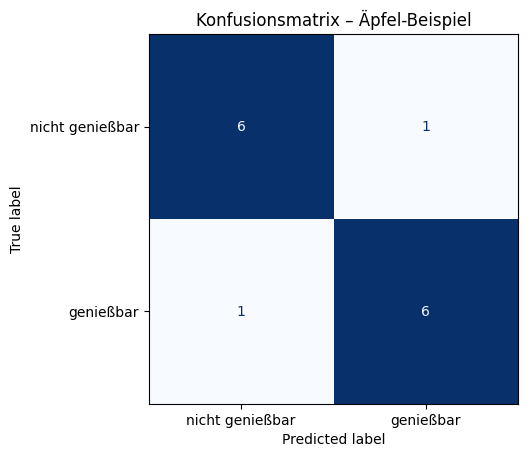

In [9]:
cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["nicht genießbar", "genießbar"]
)

disp.plot(
    cmap="Blues",           # Farbschema: Blues, Greens, Oranges ...
    colorbar=False,         # Farbskala rechts ausblenden
    values_format="d"       # ganze Zahlen statt wissenschaftlicher Notation
)

plt.title("Konfusionsmatrix – Äpfel-Beispiel")
plt.show()

## 8. Kleine Übung

**Aufgabe 1:**  
Bestimmen Sie mit `predict_proba()` die Wahrscheinlichkeit für Klasse 1 für die Werte 5, 7 und 10.

**Aufgabe 2:**  
Erklären Sie in Worten:
- Warum ist 0,5 ein sinnvoller Standardschwellwert?
- Warum liefert die logistische Regression zunächst Wahrscheinlichkeiten und nicht direkt Klassen?

## 8. Kleine Übung – Musterlösung

In [ ]:
# Drei Äpfel mit unterschiedlichen Ernte-Tagen testen
X_beispiel = np.array([[5], [7], [10]])  # 2D-Array: eine Spalte, drei Zeilen

# predict_proba gibt zwei Spalten zurück: P(Klasse 0) und P(Klasse 1)
# Mit [:, 1] wählen wir nur die zweite Spalte (= P(genießbar))
wahrscheinlichkeiten = clf.predict_proba(X_beispiel)[:, 1]
vorhersagen          = clf.predict(X_beispiel)

# Ergebnisse Zeile für Zeile ausgeben
for i in range(len(X_beispiel)):
    x    = X_beispiel[i, 0]           # Erntetag
    p    = wahrscheinlichkeiten[i]     # Wahrscheinlichkeit für "genießbar"
    pred = vorhersagen[i]              # Vorhergesagte Klasse (0 oder 1)
    print(f"x = {x:>2}: P(Klasse 1) = {p:.3f},  Vorhersage = {pred}")

## Erlaeuterung fuer Studierende

### Was macht `predict_proba()`?

Die Methode `predict_proba()` gibt fuer jeden Datenpunkt **zwei Wahrscheinlichkeiten** zurueck:

```python
model.predict_proba([[5], [7], [10]])
# Ausgabe (Beispiel):
# [[0.82, 0.18],   -> x=5:  82% Klasse 0,  18% Klasse 1
#  [0.41, 0.59],   -> x=7:  41% Klasse 0,  59% Klasse 1
#  [0.03, 0.97]]   -> x=10:  3% Klasse 0,  97% Klasse 1
```

---

### Warum 0.5 als Standardschwellwert?

```
P(Klasse 1) >= 0.5  ->  Vorhersage: Klasse 1
P(Klasse 1) <  0.5  ->  Vorhersage: Klasse 0
```

0.5 ist der neutrale Mittelpunkt: das Modell ist gleich sicher fuer beide Klassen.
In der Praxis kann der Schwellwert aber angepasst werden.

---

### Schwellwert-Anpassung: Precision vs. Recall

**Beispiel Lebensmittelkontrolle:**
Lieber zu vorsichtig (mehr falsche Alarme, aber kein verdorbener Apfel wird verkauft)
als zu nachlassig (weniger falsche Alarme, aber manche schlechten Aepfel gelangen zum Kunden).

In solchen Faellen senkt man den Schwellwert -- z.B. auf 0.3:

| Schwellwert | Effekt | Precision | Recall |
|:---:|---|:---:|:---:|
| 0.5 (Standard) | Neutrale Entscheidung | hoeher | niedriger |
| 0.3 (gesenkt) | Vorsichtiger: mehr Klasse 1 | niedriger | hoeher |

> **Merksatz:** `predict()` ist die fertige Entscheidung. `predict_proba()` eroeffnet
> die Moeglichkeit, den Schwellwert flexibel anzupassen.


## Schwellwert-Anpassung im Code

Der Standard-Schwellwert 0.5 kann manuell veraendert werden.
Wir vergleichen die Auswirkung auf Precision und Recall:


In [ ]:
# Wahrscheinlichkeiten fuer alle Trainingspunkte
proba_train = clf.predict_proba(X)[:, 1]   # P(Klasse 1)

print("Vergleich verschiedener Schwellwerte:")
print(f"{'Schwellwert':>12} | {'Precision':>10} | {'Recall':>8} | {'F1':>8}")
print("-" * 48)

for schwellwert in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_sw = (proba_train >= schwellwert).astype(int)
    # Nur berechnen wenn beide Klassen in Vorhersage vorkommen
    if len(set(y_pred_sw)) > 1:
        p = precision_score(y, y_pred_sw)
        r = recall_score(y, y_pred_sw)
        f = f1_score(y, y_pred_sw)
        marker = " <- Standard" if schwellwert == 0.5 else ""
        print(f"{schwellwert:>12.1f} | {p:>10.3f} | {r:>8.3f} | {f:>8.3f}{marker}")
    else:
        print(f"{schwellwert:>12.1f} | nur eine Klasse vorhergesagt")

print()
print("Beobachtung: niedrigerer Schwellwert -> hoeher Recall, niedrigere Precision")
print("            hoeher Schwellwert    -> hoehere Precision, niedrigerer Recall")


### Musterantworten

**Warum ist 0,5 ein sinnvoller Standardschwellwert?**  
Bei binärer Klassifikation trennt 0,5 die beiden Klassen genau an dem Punkt, an dem das Modell beide Klassen gleich wahrscheinlich einschätzt.

**Warum liefert die logistische Regression zunächst Wahrscheinlichkeiten?**  
Weil das Modell die Zugehörigkeit zu Klasse 1 auf einer Skala zwischen 0 und 1 schätzt. Erst durch einen Schwellwert entsteht daraus eine konkrete Klassenentscheidung.
